In [1]:
import os
import re
import ast
import json
import random
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt

from util import *

### initiate vars

In [4]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

all_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [5]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1',
#               'male_dem_ny_1',
#               'male_rep_ny_1',
#               'female_dem_ny_1',
#               'female_rep_ny_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### pick comment for manual annotation

In [19]:
random.seed(36)
rand_indices = random.sample(range(merged_df.shape[0]), 50)

In [20]:
merged_df = merged_df[merged_df['Main Topic'] == 'Political']
merged_df.shape

(827, 16)

In [21]:
merged_df.iloc[rand_indices][['account', 'urlid', 'caption', 'chronological_comment']].to_clipboard()

### api setup

In [2]:
news_df = pd.read_csv('/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news_comments.csv')
news_df.shape

(1279, 13)

In [3]:
news_df.dropna(subset=['caption'], inplace=True)
news_df.shape

(1129, 13)

In [4]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [5]:
for url in news_df['urlid'].unique().tolist():
    if news_df[news_df['urlid'] == url]['caption_text'].nunique() != 1:
        print(url, news_df[news_df['urlid'] == url]['caption_text'].nunique())

In [6]:
url_caption_map = {}

for url in news_df['urlid'].unique().tolist():
    comments = news_df[news_df['urlid'] == url]['caption_text'].unique()[0]

    url_caption_map[url] = comments

In [7]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

comment_caption_map = {}
for caption in news_df['caption_text'].tolist():
    if caption not in comment_caption_map:
        comment_caption_map[caption] = []
    for col in cols:
        temp = news_df[news_df['caption_text'] == caption][col].tolist()
        comment_caption_map[caption] += temp

    comment_caption_map[caption] = list(set(comment_caption_map[caption]))

In [20]:
count = 0

for k, v in comment_caption_map.items():
    count+=len(v)

count

1013

In [17]:
for caption, texts in comment_caption_map.items():
    for text in texts:
        if pd.notna(text):
            x = ast.literal_eval(text)
            username = x[0]
            comment = x[1]

In [22]:
# TODO: change this to load from env or config file

client = OpenAI(api_key=api_key)

In [23]:
labels_df = pd.DataFrame(columns=['username', 'caption', 'comment', 'label'])

count = 0
for caption, texts in comment_caption_map.items():
    for text in texts:
        if pd.notna(text):
            x = ast.literal_eval(text)
            username = x[0]
            comment = x[1]

        prompt = f"""
        You are a researcher annotating Instagram posts from news outlets.
        Given the caption of an Instagram post and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
        Label the comment as one of the following categories:
        - Supportive: The comment expresses agreement, approval, or positive sentiment towards the content of the caption.
        - Against: The comment expresses disagreement, disapproval, or negative sentiment towards the content of the caption.
        - Neutral: The comment neither supports nor opposes the content of the caption; it may be factual or unrelated in tone.

        Caption: "{caption}"
        Comment: "{comment}"

        Label:
        """

        response = client.chat.completions.create(
            model="gpt-5.2",
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        label = response.choices[0].message.content.strip()

        labels_df = pd.concat([labels_df, pd.DataFrame({'username': [username],
                                                        'caption': [caption], 'comment': [comment],
                                                        'label': [label]})], ignore_index=True)

        count += 1

        print(count) 

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259


In [14]:
labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='gpt annotations no account')

In [15]:
labels_df

,account,username,caption,comment,label
0,breitbart,ryan.smith202,Speaking to Editor-in-Chief Alex Marlow @marlo...,"It’s not fissures in MAGA, it fissures in Amer...",Supportive
1,breitbart,terp00,Speaking to Editor-in-Chief Alex Marlow @marlo...,Maga died when trump went Israel first over Am...,Against
2,breitbart,_taco_______,Speaking to Editor-in-Chief Alex Marlow @marlo...,🤡🤡,Against
3,breitbart,loretta.bauer.35,Speaking to Editor-in-Chief Alex Marlow @marlo...,I thought that was exactly why we voted for Tr...,Supportive
4,breitbart,torinejudith,Speaking to Editor-in-Chief Alex Marlow @marlo...,❤️,Supportive
...,...,...,...,...,...
819,washingtonpost,brianmpalmieri,In an era defined by major political divisions...,We need to take back at least half of their co...,Against
820,washingtonpost,nd3,In an era defined by major political divisions...,Take the money out of politics! Simple.,Supportive
821,washingtonpost,tylerlizenby,In an era defined by major political divisions...,It costs less than 10% of their wealth to buy ...,Against
822,washingtonpost,tessakaneene,In an era defined by major political divisions...,"We know, babe. We've known.",Neutral


In [13]:
url_caption_map_reverse = {v:k for k, v in url_caption_map.items()}
url_caption_map_reverse

labels_df['urlid'] = labels_df['caption'].apply(lambda x: url_caption_map_reverse[x] if x in url_caption_map_reverse else -1)

In [16]:
labels_df['urlid'] = labels_df['urlid'].replace({-1: 'DRYXH9GlIcS'})

In [18]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(labels_df['urlid'].unique().tolist())]
posts_data.shape[0] == labels_df['urlid'].nunique()

labels_df = pd.merge(labels_df, posts_data, on='urlid', how='inner')
labels_df.drop(columns=['Url'], inplace=True)
labels_df.drop(columns=['Brahmani_Topics', 'Divya_Topics', 'Hamayoon_Topics'], inplace=True)
labels_df.shape

(824, 7)

In [30]:
labels_df.head()

,account,username,caption,comment,label,urlid,main_topic
0,breitbart,ryan.smith202,Speaking to Editor-in-Chief Alex Marlow @marlo...,"It’s not fissures in MAGA, it fissures in Amer...",Supportive,DRWBiQXDG0H,Political
1,breitbart,terp00,Speaking to Editor-in-Chief Alex Marlow @marlo...,Maga died when trump went Israel first over Am...,Against,DRWBiQXDG0H,Political
2,breitbart,_taco_______,Speaking to Editor-in-Chief Alex Marlow @marlo...,🤡🤡,Against,DRWBiQXDG0H,Political
3,breitbart,loretta.bauer.35,Speaking to Editor-in-Chief Alex Marlow @marlo...,I thought that was exactly why we voted for Tr...,Supportive,DRWBiQXDG0H,Political
4,breitbart,torinejudith,Speaking to Editor-in-Chief Alex Marlow @marlo...,❤️,Supportive,DRWBiQXDG0H,Political


In [86]:
label_comment_mapping = {}

for x, y, z in zip(labels_df['username'], labels_df['comment'], labels_df['label']):
    label_comment_mapping[(x, y)] = z

In [87]:
label_comment_mapping

{('ryan.smith202',
  'It’s not fissures in MAGA, it fissures in America first and only against the globalists.'): 'Supportive',
 ('terp00', 'Maga died when trump went Israel first over America.'): 'Against',
 ('_taco_______', '🤡🤡'): 'Against',
 ('loretta.bauer.35',
  'I thought that was exactly why we voted for Trump. We already knew this and we will not stop fighting for our country'): 'Supportive',
 ('torinejudith', '❤️'): 'Supportive',
 ('xduggitx', 'Maga is dead. America First and Only ✝️🇺🇸'): 'Against',
 ('i_tr00per',
  'Bernie Moreno has the most remedial and low opinion of what his voters want, if he thinks that is all America First is looking for he is just another oit of touch RINO.'): 'Against',
 ('i_tr00per',
  'AMERICA FIRST !! ONLY !! THE CORPORATE RINOS MUST BE DESTROYED !'): 'Supportive',
 ('i_tr00per',
  'WE ARE NOT COMING TOGETHER UNTIL THE GOP BECOMES AMERICA FIRST!! AMERICA FIRST EITHER TAKES OVER THE GOP OR WE DESTROY THE GOP ALL TOGETHER !!'): 'Against',
 ('alton_k

In [89]:


temp = []
for loc in news_df['male_dem_ny_1_comment']:
    if pd.notna(loc):
        try:
            temp.append(label_comment_mapping[ast.literal_eval(loc)])
        except:
            print(ast.literal_eval(loc))

('scottishlyme', 'The actual LEFT should be called NEO COMMUNISM (its proper name because that is what it is) and all it’s different alliances should be named as well…alliance with the Globalists, alliance with the Islamists, even alliance with the Neo Nazi')
('jordanbeasley626', 'Dont blame her. Shes seen the real. Im glad she stood up for the victims tho 🙏 god bless her')
('matt.mccaffrey', 'MTG is a Champion for America. This is very sad.')
('scottishraven', 'She’s a wonderful woman I’ve always admired her,she will be sorely missed ❤️')
('alamarranchdidactics', 'Losing free thinkers and those who speak their mind is not good for the country…')
('nancyoninstagram', '❤️❤️❤️❤️❤️👏👏👏👏👏')
('the_sapphire_turtle', 'Ugh...I should have joined the Air Force when I had the chance.')
('cozy__mark', '#BanShariaLaw in America')
('jimby.44', 'Boom')
('genxkay', 'Sorry but this is not accurate the way it is written. I’m conservative and these numbers do not add up . Just saying if that’s supposed t

In [92]:
labels_df[labels_df['username'] == 'crash.nn.burn']

,account,username,caption,comment,label,urlid,main_topic


In [91]:
for k, v in label_comment_mapping:
    if k[0] == 'jordanbeasley626':
        print(k, v)

In [ ]:
news_df['male_dem_ny_1_comment_label'] = news_df['male_dem_ny_1_comment'].apply

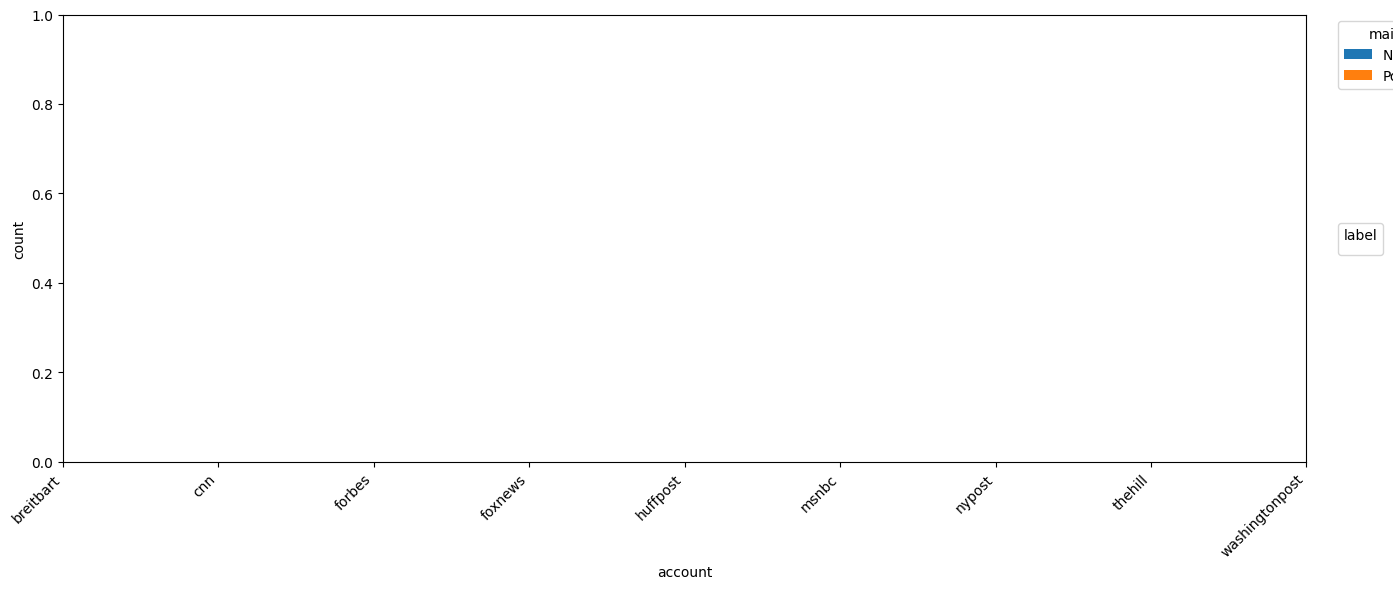

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# counts: (account, label, main_topic)
pivot = (labels_df
         .groupby(['account', 'label', 'main_topic'])
         .size()
         .unstack('main_topic', fill_value=0))  # index: (account,label) ; cols: main_topic

accounts = pivot.index.get_level_values('account').unique()

# bar categories you want (and their order)
labels = ['support', 'against', 'none']
labels = [l for l in labels if l in pivot.index.get_level_values('label').unique()]

# keep exactly two main_topic columns (set explicitly if you want)
topics = list(pivot.columns)
if len(topics) > 2:
    topics = topics[:2]
pivot = pivot.reindex(columns=topics, fill_value=0)

x = np.arange(len(accounts))
width = 0.8 / max(len(labels), 1)

# fixed colors: blue/orange for main_topic
colors = ['C0', 'C1']

# hatches to identify which bar is which label
hatch_map = {
    'support': '///',
    'against': '\\\\\\',
    'none': '...'
}

fig, ax = plt.subplots(figsize=(14, 6))

for i, lab in enumerate(labels):
    mat = pivot.xs(lab, level='label').reindex(accounts, fill_value=0)

    xpos = x + (i - (len(labels) - 1) / 2) * width
    bottom = np.zeros(len(accounts))

    for k, topic in enumerate(topics):
        ax.bar(
            xpos,
            mat[topic].to_numpy(),
            width=width,
            bottom=bottom,
            color=colors[k],
            hatch=hatch_map.get(lab, None),
            edgecolor='black',
            linewidth=0.6
        )
        bottom += mat[topic].to_numpy()

# axes
ax.set_xticks(x)
ax.set_xticklabels(accounts, rotation=45, ha='right')
ax.set_xlabel('account')
ax.set_ylabel('count')

# two legends: main_topic (colors) + label (hatches)
topic_handles = [Patch(facecolor=colors[i], label=str(t)) for i, t in enumerate(topics)]
label_handles = [Patch(facecolor='white', edgecolor='black',
                       hatch=hatch_map.get(l, None), label=l) for l in labels]

leg1 = ax.legend(handles=topic_handles, title='main_topic',
                 bbox_to_anchor=(1.02, 1), loc='upper left')
ax.add_artist(leg1)
ax.legend(handles=label_handles, title='label',
          bbox_to_anchor=(1.02, 0.55), loc='upper left')

plt.tight_layout()
plt.show()


In [43]:
# labels_df = pd.DataFrame(columns=['account', 'caption', 'comment', 'label'])
# for account, caption, comment in zip(comments_df['account'], comments_df['caption'], comments_df['chronological_comment']):
#     prompt = f"""
#     You are a researcher annotating Instagram posts from news outlets.
#     Given the caption of an Instagram post and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
#     Label the comment as one of the following categories:
#     - Supportive: The comment expresses agreement, approval, or positive sentiment towards the content of the caption.
#     - Against: The comment expresses disagreement, disapproval, or negative sentiment towards the content of the caption.
#     - Neutral: The comment neither supports nor opposes the content of the caption; it may be factual or unrelated in tone.

#     Caption: "{caption}"
#     Account: "{account}"
#     Comment: "{comment}"

#     Label:
#     """

#     response = client.chat.completions.create(
#         model="gpt-5.2",
#         messages=[{"role": "user", "content": prompt}],
#         temperature=0
#     )

#     label = response.choices[0].message.content.strip()

#     labels_df = pd.concat([labels_df, pd.DataFrame({'account': [account], 'caption': [caption], 'comment': [comment], 'label': [label]})], ignore_index=True)

In [49]:
# labels_df = pd.DataFrame(columns=['account', 'caption', 'comment', 'label'])
# for account, caption, comment in zip(comments_df['account'], comments_df['caption'], comments_df['chronological_comment']):
#     prompt = f"""
#     You are a researcher annotating Instagram posts from news outlets.
#     Given the caption of an Instagram post and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
#     Label the comment as one of the following categories:
#     - Left leaning
#     - Right leaning
#     - Neutral

#     Caption: "{caption}"
#     Comment: "{comment}"

#     Label:
#     """

#     response = client.chat.completions.create(
#         model="gpt-5.2",
#         messages=[{"role": "user", "content": prompt}],
#         temperature=0
#     )

#     label = response.choices[0].message.content.strip()

#     labels_df = pd.concat([labels_df, pd.DataFrame({'account': [account], 'caption': [caption], 'comment': [comment], 'label': [label]})], ignore_index=True)

In [52]:
# labels_df = pd.DataFrame(columns=['account', 'caption', 'comment', 'label'])
# for account, caption, comment in zip(comments_df['account'], comments_df['caption'], comments_df['chronological_comment']):
#     prompt = f"""
#     You are a researcher annotating Instagram posts from news outlets.
#     Given the caption of an Instagram post, the news outlet where it was posted and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
#     Label the comment as one of the following categories:
#     - Left leaning
#     - Right leaning
#     - Neutral

#     Caption: "{caption}"
#     Account: "{account}"
#     Comment: "{comment}"

#     Label:
#     """

#     response = client.chat.completions.create(
#         model="gpt-5.2",
#         messages=[{"role": "user", "content": prompt}],
#         # temperature=0
#     )

#     label = response.choices[0].message.content.strip()

#     labels_df = pd.concat([labels_df, pd.DataFrame({'account': [account], 'caption': [caption], 'comment': [comment], 'label': [label]})], ignore_index=True)